# Water Cost of Intelligence (WCI)
## A Framework for Estimating Freshwater Consumption per AI Query
 
---

## Abstract

This notebook implements the **Water Cost of Intelligence (WCI)** metric, which estimates the total freshwater consumed per AI query by combining:
1. **Direct water** (on-site cooling, measured by WUE) — definition: Green Grid WP#35 (WUE_v1.pdf)
2. **Indirect water** (electricity generation, measured by EWIF) — definition: NREL TP-550-33905 (via Green Grid WP#35)

We validate against Google's publicly reported **0.26 mL** per Gemini prompt (Elsworth et al. 2025, arXiv:2508.15734) and show that accounting for indirect water increases the true consumption by **179–310%** using conservative to moderate EWIF assumptions.

---

## Important Notes on Data Sources

- All energy data come from **published disclosures only**
- **Water consumption** (evaporated, not returned) is used throughout — NOT withdrawal
- All assumptions are explicitly flagged with `# ASSUMPTION:` comments
- Every number is cited inline at the point of use



- **Sam Altman blog** (Task 2) — https://blog.samaltman.com/the-gentle-singularity
- **Google blog — AI inference** (Task 1) — https://cloud.google.com/blog/products/infrastructure/measuring-the-environmental-impact-of-ai-inference/
- **Epoch AI ChatGPT energy** (Task 3) — https://epoch.ai/gradient-updates/how-much-energy-does-chatgpt-use/
- **NREL TP-550-33905** (Task 5b) — https://www.nrel.gov/docs/fy04osti/33905.pdf
- **Mytton 2021** (Task 5b) — https://www.nature.com/articles/s41545-021-00101-w
- **Siddik et al. 2021** (Task 5b) — https://doi.org/10.1088/1748-9326/abfba1
- **WRI Aqueduct** (Task 5c) — https://www.wri.org/aqueduct
- **WULCA AWARE** (Task 5c) — https://wulca-waterlca.org/aware/
- **Google Environmental Report 2025** (Task 5a) — https://www.gstatic.com/gumdrop/sustainability/google-2025-environmental-report.pdf
- **AWS Sustainability Report 2023** (Task 5a) — https://sustainability.aboutamazon.com/
- **Microsoft DC sustainability** (Task 5a) — https://datacenters.microsoft.com/sustainability/efficiency/
- **Meta Sustainability Report** (Task 5a) — https://sustainability.atmeta.com/
- **Thunder Said Energy — per-fuel water intensity** (Task 5b) — https://thundersaidenergy.com/
- **Shaolei Ren critique** (Task 7) — The Verge + DataCenterDynamics
- **EESI data-center water brief** (Task 5a) — https://www.eesi.org/


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent styling
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('colorblind')
path = '/Users/amittiwari/Desktop/Course Document/Research/Water Research'

---
## Task 1: Key Concepts and WCI Formula

### Definitions

| Term | Definition | Units |
|------|-----------|-------|
| **WUE** | Water Usage Effectiveness — liters consumed on-site for cooling per kWh IT energy | L/kWh |
| **EWIF** | Energy Water Intensity Factor — liters consumed at power plants to generate 1 kWh | L/kWh |
| **PUE** | Power Usage Effectiveness — total facility energy / IT equipment energy | dimensionless |
| **WSI** | Water Stress Index — scarcity score for the location (Aqueduct 0–5 scale) | dimensionless |

### WCI Formula

$$W_{direct} = \frac{E_{query} \times (1 - f_{overhead})}{1000} \times WUE \times 1000 \quad [\text{mL}]$$

$$W_{indirect} = \frac{E_{query}}{1000} \times PUE \times EWIF \times 1000 \quad [\text{mL}]$$

$$WCI_{total} = W_{direct} + W_{indirect} \quad [\text{mL}]$$

$$WCI_{stress} = WCI_{total} \times WSI \quad [\text{mL, scarcity-adjusted}]$$

Where $E_{query}$ is in Wh, $f_{overhead}$ is the fraction of energy consumed by data center overhead (PUE overhead).

**Key insight:** Google's reported 0.26 mL per Gemini prompt equals only $W_{direct}$. $W_{indirect}$ — water consumed at power plants — is omitted from industry reporting.

---
## Task 2: Official Energy Data Collection

In [2]:
# ============================================================
# TASK 2: OFFICIAL ENERGY DATA FROM PUBLISHED DISCLOSURES
# ============================================================

# --- Google Gemini ---
# Source: Elsworth et al. (2025) "Measuring the environmental impact of delivering AI
#   at Google Scale" arXiv:2508.15734v1, Table 1 & 2, May 2025 measurement.
google_energy_wh       = 0.24    # Wh per median text prompt (Comprehensive Approach)
google_water_direct_mL = 0.26    # mL — DIRECT COOLING ONLY (ISO WUE Category 2)
google_carbon_mb       = 0.03    # gCO2e, market-based (with renewable energy credits)
google_carbon_lb       = 0.09    # gCO2e, location-based (without RE credits) [ESTIMATED]
google_pue             = 1.09    # Fleet-average PUE (Google Environmental Report 2025)
google_wue_cat2        = 1.15    # L/kWh ISO WUE Category 2 (Section 3.3 of Google paper)
google_overhead_frac   = 0.08    # Overhead energy fraction (8% of total, Table 1)

# Google note from paper: Water = (ETotal - EOverhead) × WUE_Cat2
# Overhead excluded because it's already captured in PUE

# --- OpenAI GPT-4o ---
# Source: Sam Altman, "The Gentle Singularity" blog, June 2025
#   URL: https://blog.samaltman.com/the-gentle-singularity
#   Figures cross-validated: Jegham et al. (2025) Section 5.3 cite Altman's 0.34 Wh figure
#   and estimate 0.42 Wh (±0.13) — within 1 SD of Altman's disclosure.
openai_energy_wh       = 0.34    # Wh per average query (MEAN, not median)
openai_water_direct_mL = 0.32    # ~0.000085 gallons × 3785.41 mL/gal ≈ 0.322 mL
                                  # NOTE: Altman did not specify direct-only vs. total
openai_pue             = 1.12    # AWS global PUE (AWS Sustainability Report 2023)
openai_wue             = 0.19    # AWS global WUE (AWS Sustainability Report 2023)
                                  # NOTE: OpenAI's actual WUE not disclosed; AWS used as host proxy
openai_overhead_frac   = 0.09    # ASSUMPTION: ~9% overhead, consistent with AWS PUE=1.12

# Create comparison table
official_data = pd.DataFrame({
    'Parameter': [
        'Energy per query (Wh)', 
        'Reported water (mL)',
        'Water scope',
        'Carbon (gCO2e)',
        'PUE',
        'WUE (L/kWh)',
        'Metric reported',
        'Measurement period',
        'Source'
    ],
    'Google Gemini': [
        '0.24', '0.26', 'Direct cooling ONLY',
        '0.03 (market-based)', '1.09', '1.15',
        'Median', 'May 2025',
        'Elsworth et al. arXiv:2508.15734'
    ],
    'OpenAI GPT-4o': [
        '0.34', '~0.32', 'Unknown (likely direct)',
        'Not disclosed', '1.12 (AWS proxy)', '0.19 (AWS proxy)',
        'Mean', 'June 2025',
        'Sam Altman blog "The Gentle Singularity"'
    ]
})

print('=== TABLE: Official Energy & Water Disclosures ===')
print(official_data.to_string(index=False))
#CAVEATS:
#1. Google reports MEDIAN; Altman reports MEAN — not directly comparable
#2. Google water = direct cooling only; indirect (electricity) excluded
#3. OpenAI WUE & PUE are AWS proxies — actual values undisclosed
#4. Google uses market-based carbon (lower); location-based = ~0.09 gCO2e

=== TABLE: Official Energy & Water Disclosures ===
            Parameter                    Google Gemini                            OpenAI GPT-4o
Energy per query (Wh)                             0.24                                     0.34
  Reported water (mL)                             0.26                                    ~0.32
          Water scope              Direct cooling ONLY                  Unknown (likely direct)
       Carbon (gCO2e)              0.03 (market-based)                            Not disclosed
                  PUE                             1.09                         1.12 (AWS proxy)
          WUE (L/kWh)                             1.15                         0.19 (AWS proxy)
      Metric reported                           Median                                     Mean
   Measurement period                         May 2025                                June 2025
               Source Elsworth et al. arXiv:2508.15734 Sam Altman blog "The Gentle Si

---
## Task 3: Per-Token Energy Derivation

**Critical limitation:** Neither Google nor OpenAI specifies token counts for their reported queries. We must make assumptions, which are documented below.

In [3]:
# ============================================================
# TASK 3: PER-TOKEN ENERGY RATES
# ============================================================

# --- Google ---
# ASSUMPTION: Google median prompt ≈ 300 total tokens
# Rationale: The Google paper does not specify token counts. 300 tokens
# represents a typical short chat exchange (~150 input + ~150 output).
# This is consistent with the paper describing a "median text prompt" for
# an AI assistant, which skews short in production (long tail excluded by median).
# Flag: This assumption is the largest source of uncertainty in cross-prompt scaling.
GOOGLE_ASSUMED_TOKENS = 300  # ASSUMPTION — flag in paper
google_energy_wh = 0.24
google_e_per_token_wh = google_energy_wh / GOOGLE_ASSUMED_TOKENS

# --- OpenAI ---
# Source: Epoch AI (2025) estimated ~500 output tokens for typical ChatGPT query.
#   URL: https://epoch.ai/gradient-updates/how-much-energy-does-chatgpt-use
#   This is cited by task doc (Task 3) and consistent with Jegham et al. (2025)
#   medium prompt definition (1000 input + 1000 output = 2000 tokens).
#   We use 500 as it reflects output token count, consistent with Epoch AI.
# ASSUMPTION: OpenAI average query ≈ 500 total tokens (Epoch AI, 2025)
OPENAI_ASSUMED_TOKENS = 500  # ASSUMPTION — sourced from Epoch AI
openai_energy_wh = 0.34
openai_e_per_token_wh = openai_energy_wh / OPENAI_ASSUMED_TOKENS

print('=== PER-TOKEN ENERGY RATES ===')
print(f'Google Gemini:')
print(f'  Assumed tokens: {GOOGLE_ASSUMED_TOKENS} (ASSUMPTION — not in paper)')
print(f'  Energy/query: {google_energy_wh} Wh')
print(f'  → Energy/token: {google_e_per_token_wh*1e6:.2f} µWh ({google_e_per_token_wh:.6f} Wh)')
print()
print(f'OpenAI GPT-4o:')
print(f'  Assumed tokens: {OPENAI_ASSUMED_TOKENS} (Epoch AI, 2025)')
print(f'  Energy/query: {openai_energy_wh} Wh')
print(f'  → Energy/token: {openai_e_per_token_wh*1e6:.2f} µWh ({openai_e_per_token_wh:.6f} Wh)')
print()
print('LIMITATIONS (must appear in paper):')
print('  • Energy does NOT scale linearly with tokens:')
print('    - Prefill (input) phase ≈ 0.8 J/token (parallel processing, more efficient)')
print('    - Decode (output) phase ≈ 2.0 J/token (autoregressive, less efficient)')
print('    Source: Kaur et al. (2026), Section 3.5, citing Samsi et al. (2023)')
print('  • Our per-token rate is an average blend — appropriate for macro comparisons')
print('    but not for precise prefill/decode decomposition')

=== PER-TOKEN ENERGY RATES ===
Google Gemini:
  Assumed tokens: 300 (ASSUMPTION — not in paper)
  Energy/query: 0.24 Wh
  → Energy/token: 800.00 µWh (0.000800 Wh)

OpenAI GPT-4o:
  Assumed tokens: 500 (Epoch AI, 2025)
  Energy/query: 0.34 Wh
  → Energy/token: 680.00 µWh (0.000680 Wh)

LIMITATIONS (must appear in paper):
  • Energy does NOT scale linearly with tokens:
    - Prefill (input) phase ≈ 0.8 J/token (parallel processing, more efficient)
    - Decode (output) phase ≈ 2.0 J/token (autoregressive, less efficient)
    Source: Kaur et al. (2026), Section 3.5, citing Samsi et al. (2023)
  • Our per-token rate is an average blend — appropriate for macro comparisons
    but not for precise prefill/decode decomposition


---
## Task 4: Prompt Size Tiers and Use Case Mapping

In [4]:
# ============================================================
# TASK 4: PROMPT TIERS
#  FLAG — Tier definitions differ from the task brief.
#    Task doc (Task 4): Short ~200, Medium ~300, Long ~7,000 tokens
#    Here (used): Jegham et al. (2025) arXiv:2505.09598 §4.2 definitions
#      Short:  100 in  + 300 out  =  400 tokens
#      Medium: 1000 in + 1000 out = 2000 tokens
#      Long:  10000 in + 1500 out = 11500 tokens
#    VERIFY with team which definition to publish. If task-doc values are required,
#    set prompt_tiers[*]['tokens'] to 200 / 300 / 7000.
# Source used: Jegham et al. (2025) arXiv:2505.09598 §4.2
# ============================================================

prompt_tiers = {
    'Short':  {
        'tokens': 400,
        'input_tokens': 100,
        'output_tokens': 300,
        'use_cases': 'Q&A ("capital of France?"), fact lookup, classification, quick chatbot'
    },
    'Medium': {
        'tokens': 2000,
        'input_tokens': 1000,
        'output_tokens': 1000,
        'use_cases': 'Email drafting, code completion, paragraph translation, short summarization'
    },
    'Long':   {
        'tokens': 11500,
        'input_tokens': 10000,
        'output_tokens': 1500,
        'use_cases': 'Document analysis, legal review, research paper summarization, long-form generation'
    },
}

# Calculate energy per tier
for tier, info in prompt_tiers.items():
    info['google_energy_wh'] = google_e_per_token_wh * info['tokens']
    info['openai_energy_wh'] = openai_e_per_token_wh * info['tokens']

# Build table
tier_df = pd.DataFrame([
    {
        'Tier': tier,
        'Total Tokens': info['tokens'],
        'Input Tokens': info['input_tokens'],
        'Output Tokens': info['output_tokens'],
        'Google Energy (Wh)': f"{info['google_energy_wh']:.4f}",
        'OpenAI Energy (Wh)': f"{info['openai_energy_wh']:.4f}",
        'Real-World Use Cases': info['use_cases'][:45] + '...'
    }
    for tier, info in prompt_tiers.items()
])

print(tier_df.to_string(index=False))


  Tier  Total Tokens  Input Tokens  Output Tokens Google Energy (Wh) OpenAI Energy (Wh)                             Real-World Use Cases
 Short           400           100            300             0.3200             0.2720 Q&A ("capital of France?"), fact lookup, clas...
Medium          2000          1000           1000             1.6000             1.3600 Email drafting, code completion, paragraph tr...
  Long         11500         10000           1500             9.2000             7.8200 Document analysis, legal review, research pap...


---
## Task 5: Water Multiplier Data

In [5]:
# ============================================================
# TASK 5a: WUE VALUES (Water for Cooling — consumption basis)
# ============================================================
# CRITICAL: These are CONSUMPTION figures (water evaporated, not returned)
# NOT withdrawal figures. Withdrawal is always higher.
# Source distinction: Li et al. (2025) CACM notes Google consumes ~80% of what it withdraws.
#
#  Added row: "Average across data centers — 1.9 L/kWh (EESI)" per task-doc Task 5a.
#    EESI source URL: https://www.eesi.org/  — must verify.

wue_data = pd.DataFrame([
    # Google fleet — inline citation: Elsworth et al. 2025, arXiv:2508.15734 §3.3
    {'Source': 'Google fleet (WUE Cat2)',    'WUE_L_kWh': 1.15, 'Year': 2024,
     'Reference': 'Elsworth et al. (2025) arXiv:2508.15734, Sec 3.3'},
    # AWS — inline citation: AWS Sustainability Report 2023 via Jegham et al. Table 1
    {'Source': 'AWS global',                 'WUE_L_kWh': 0.19, 'Year': 2023,
     'Reference': ' AWS Sustainability Report 2023  (via Jegham et al. 2025, Table 1)'},
    {'Source': 'Microsoft global',           'WUE_L_kWh': 0.30, 'Year': 2024,
     'Reference': ' Microsoft datacenters.microsoft.com/sustainability/efficiency/'},
    {'Source': 'Microsoft Arizona (hot/dry)', 'WUE_L_kWh': 1.52, 'Year': 2024,
     'Reference': ' Microsoft datacenters.microsoft.com/sustainability/efficiency/ '},
    {'Source': 'Meta newest facilities',     'WUE_L_kWh': 0.20, 'Year': 2023,
     'Reference': ' Meta Sustainability Report 2024 '},
    {'Source': 'Industry average (Meta/Green Grid)',
     'WUE_L_kWh': 1.80, 'Year': 2023,
     'Reference': 'Li et al. 2025 (CACM); Green Grid WP#35 (WUE_v1.pdf)'},
    {'Source': 'Average across data centers (EESI) ',
     'WUE_L_kWh': 1.90, 'Year': None,
     'Reference': ' EESI (https://www.eesi.org/); task doc Task 5a'},
    {'Source': 'Arizona (summer peak, est.)', 'WUE_L_kWh': 9.00, 'Year': 2023,
     'Reference': 'Li et al. 2025 (CACM) — cooling-tower Arizona summer peak'},
])

print('=== TABLE 5a: WUE Values (Consumption Basis) ===')
print(wue_data.to_string(index=False))
print()
print('NOTE: OpenAI/Anthropic WUE not publicly disclosed.')
print('       We use AWS global WUE (0.19 L/kWh) as proxy.')


=== TABLE 5a: WUE Values (Consumption Basis) ===
                             Source  WUE_L_kWh   Year                                                          Reference
            Google fleet (WUE Cat2)       1.15 2024.0                   Elsworth et al. (2025) arXiv:2508.15734, Sec 3.3
                         AWS global       0.19 2023.0  AWS Sustainability Report 2023  (via Jegham et al. 2025, Table 1)
                   Microsoft global       0.30 2024.0     Microsoft datacenters.microsoft.com/sustainability/efficiency/
        Microsoft Arizona (hot/dry)       1.52 2024.0    Microsoft datacenters.microsoft.com/sustainability/efficiency/ 
             Meta newest facilities       0.20 2023.0                                   Meta Sustainability Report 2024 
 Industry average (Meta/Green Grid)       1.80 2023.0               Li et al. 2025 (CACM); Green Grid WP#35 (WUE_v1.pdf)
Average across data centers (EESI)        1.90    NaN                     EESI (https://www.eesi.org/); 

In [6]:
# ============================================================
# TASK 5b: EWIF VALUES (Water for Electricity Generation)
# ============================================================
# All values are CONSUMPTION (evaporated), not withdrawal.
# Primary source: NREL TP-550-33905 (Torcellini et al. 2003) 
#   — values cross-checked via Green Grid White Paper #35 Table A-1 (WUE_v1.pdf)
#
#  NOTE — Per-fuel values below differ slightly from the task-doc Task 5b table,
#    which cites Thunder Said Energy (https://thundersaidenergy.com/ ):
#      • Coal (wet)       : task doc ~2.0    | here 2.20
#      • Nuclear          : task doc ~2.1    | here 3.30
#      • Natural gas CCGT : task doc ~1.2    | here 0.80
#      • Gas dry cooling  : task doc 0.1–0.2 |  row added below at midpoint 0.15
#    Values here are from Green Grid WP#35 Table A-1 (downloaded).
#     VERIFY with team which set to publish; Thunder Said Energy not accessible.

EWIF_PRIMARY = 1.80   # L/kWh — NREL TP-550-33905 thermoelectric avg ( cross-checked via Green Grid WP#35)
EWIF_HIGH    = 3.10   # L/kWh — US eGRID national avg (Li et al. 2025 CACM)

ewif_data = pd.DataFrame([
    {'Source': 'US thermoelectric avg (excl. hydro)', 'EWIF_L_kWh': 1.80,
     'Notes': 'PRIMARY — conservative',
     'Reference': 'NREL TP-550-33905 ; cross-ref Green Grid WP#35 Table A-1 '},
    {'Source': 'US aggregate incl. hydro reservoir',  'EWIF_L_kWh': 7.60,
     'Notes': 'Upper bound — includes reservoir evaporation',
     'Reference': ' NREL TP-550-33905'},
    {'Source': 'US average 2015 (updated)',           'EWIF_L_kWh': 2.18,
     'Notes': 'More recent estimate',
     'Reference': ' Mytton (2021) npj Clean Water, 10.1038/s41545-021-00101-w '},
    {'Source': 'US eGRID national avg',               'EWIF_L_kWh': 3.10,
     'Notes': 'SENSITIVITY — moderate',
     'Reference': 'Li et al. 2025 (CACM), citing Reig et al. 2020'},
    {'Source': 'US regional range (balancing auth.)', 'EWIF_L_kWh': float('nan'),
     'Notes': '0.8–9.0 L/kWh depending on grid mix',
     'Reference': ' Siddik et al. (2021) ERL 10.1088/1748-9326/abfba1 '},
    {'Source': 'Wind / Solar PV',                     'EWIF_L_kWh': 0.00,
     'Notes': 'Near-zero operational water use',
     'Reference': 'Green Grid WP#35 (WUE_v1.pdf) Table A-1'},
    {'Source': 'Coal (wet cooling)',                  'EWIF_L_kWh': 2.20,
     'Notes': 'Midwest/Southeast mix',
     'Reference': 'Green Grid WP#35 Table A-1 (task doc cites Thunder Said Energy ~2.0 )'},
    {'Source': 'Nuclear',                             'EWIF_L_kWh': 3.30,
     'Notes': 'High cooling water requirement',
     'Reference': 'Green Grid WP#35 Table A-1 (task doc cites Thunder Said Energy ~2.1)'},
    {'Source': 'Natural gas CCGT',                    'EWIF_L_kWh': 0.80,
     'Notes': 'Common in Northeast US grid',
     'Reference': 'Green Grid WP#35 Table A-1 (task doc cites Thunder Said Energy ~1.2 )'},
    # NEW row added per task doc Task 5b
    {'Source': 'Natural gas — dry cooling',         'EWIF_L_kWh': 0.15,
     'Notes': 'Range 0.1–0.2 (task doc)',
     'Reference': 'Thunder Said Energy (task doc Task 5b) '},
])

print('=== TABLE 5b: EWIF Values (Consumption Basis) ===')
print(ewif_data.to_string(index=False))
print()
print(f'PRIMARY EWIF (for main analysis): {EWIF_PRIMARY} L/kWh (NREL, conservative)')
print(f'SENSITIVITY EWIF:                 {EWIF_HIGH} L/kWh (eGRID national avg)')


=== TABLE 5b: EWIF Values (Consumption Basis) ===
                             Source  EWIF_L_kWh                                        Notes                                                             Reference
US thermoelectric avg (excl. hydro)        1.80                       PRIMARY — conservative             NREL TP-550-33905 ; cross-ref Green Grid WP#35 Table A-1 
 US aggregate incl. hydro reservoir        7.60 Upper bound — includes reservoir evaporation                                                     NREL TP-550-33905
          US average 2015 (updated)        2.18                         More recent estimate            Mytton (2021) npj Clean Water, 10.1038/s41545-021-00101-w 
              US eGRID national avg        3.10                       SENSITIVITY — moderate                        Li et al. 2025 (CACM), citing Reig et al. 2020
US regional range (balancing auth.)         NaN          0.8–9.0 L/kWh depending on grid mix                    Siddik et al. (2021) ER

In [7]:
# ============================================================
# TASK 5c: WSI VALUES (Regional Water Stress)
# ============================================================
# Source: WRI Aqueduct Water Risk Atlas (https://www.wri.org/aqueduct)
#      - Li et al. 2025 (CACM) — spatiotemporal water methodology
#      - Siddik et al. 2021 — regional US DC water footprint 
# Scale: 0 = Low stress, 5 = Extremely High stress (Aqueduct 0–5)
#  USER ACTION: open https://www.wri.org/aqueduct, look up each site below,
#    and replace the WSI_Score values with the actual score + snapshot date.

wsi_data = pd.DataFrame([
    {'Location': 'The Dalles, Oregon',
     'WSI_Score': 0.5, 'Stress_Level': 'Low',
     'Major_Providers': 'Google',
     'Grid_Mix': 'Dominated by hydropower (Columbia River)',
     'EWIF_est': 0.3,
     'WSI_Source': ' WRI Aqueduct via Li et al. 2025 '},
    {'Location': 'Council Bluffs, Iowa',
     'WSI_Score': 1.0, 'Stress_Level': 'Low–Medium',
     'Major_Providers': 'Google, Meta',
     'Grid_Mix': 'Mixed coal + wind (MISO grid)',
     'EWIF_est': 1.9,
     'WSI_Source': ' WRI Aqueduct via Li et al. 2025 '},
    {'Location': 'Loudoun County, Virginia',
     'WSI_Score': 2.0, 'Stress_Level': 'Medium',
     'Major_Providers': 'AWS, Microsoft, Google',
     'Grid_Mix': 'PJM Interconnect — natural gas + nuclear',
     'EWIF_est': 2.0,
     'WSI_Source': ' WRI Aqueduct via Siddik et al. 2021 '},
    {'Location': 'Phoenix/Mesa, Arizona',
     'WSI_Score': 4.5, 'Stress_Level': 'Extremely High',
     'Major_Providers': 'Microsoft, Google',
     'Grid_Mix': 'Natural gas + nuclear (APS, SRP)',
     'EWIF_est': 1.2,
     'WSI_Source': ' WRI Aqueduct via Li et al. 2025 '},
])

print('=== TABLE 5c: Data Center Location Water Stress ===')
print(wsi_data.to_string(index=False))
print()
print(' NOTE: Aqueduct website (wri.org/aqueduct) not queried directly')
print(' AWARE characterization factors (https://wulca-waterlca.org/aware/).')
print('   Task 5c asks whether to use Aqueduct 0–5 OR AWARE m³/m³ factors. Decision pending.')
print()
print('Oregon has low stress but low EWIF (hydro). Arizona has high stress and high on-site WUE —')
print('  same query has much higher scarcity impact there.')


=== TABLE 5c: Data Center Location Water Stress ===
                Location  WSI_Score   Stress_Level        Major_Providers                                 Grid_Mix  EWIF_est                            WSI_Source
      The Dalles, Oregon        0.5            Low                 Google Dominated by hydropower (Columbia River)       0.3      WRI Aqueduct via Li et al. 2025 
    Council Bluffs, Iowa        1.0     Low–Medium           Google, Meta            Mixed coal + wind (MISO grid)       1.9      WRI Aqueduct via Li et al. 2025 
Loudoun County, Virginia        2.0         Medium AWS, Microsoft, Google PJM Interconnect — natural gas + nuclear       2.0  WRI Aqueduct via Siddik et al. 2021 
   Phoenix/Mesa, Arizona        4.5 Extremely High      Microsoft, Google         Natural gas + nuclear (APS, SRP)       1.2      WRI Aqueduct via Li et al. 2025 

 NOTE: Aqueduct website (wri.org/aqueduct) not queried directly
 AWARE characterization factors (https://wulca-waterlca.org/aware/).

---
## Task 6: WCI Calculations — All 24 Combinations

In [8]:
# ============================================================
# TASK 6: WCI CALCULATIONS (2 providers × 3 tiers × 4 regions = 24)
# ============================================================

providers = {
    'Google Gemini': {
        'pue': 1.09, 'wue': 1.15, 'overhead_frac': 0.08,
        'e_per_token': google_e_per_token_wh
    },
    'OpenAI GPT-4o': {
        'pue': 1.12, 'wue': 0.19, 'overhead_frac': 0.09,
        'e_per_token': openai_e_per_token_wh
    },
}

locations = {
    'Oregon':   {'wsi': 0.5,  'stress': 'Low'},
    'Iowa':     {'wsi': 1.0,  'stress': 'Low–Med'},
    'Virginia': {'wsi': 2.0,  'stress': 'Medium'},
    'Arizona':  {'wsi': 4.5,  'stress': 'Ext. High'},
}

def calc_wci(e_wh, pue, wue, overhead_frac, ewif=EWIF_PRIMARY):
    """Calculate WCI components in mL.
    
    W_direct: uses only (total - overhead) energy, per Google methodology.
    W_indirect: uses total IT energy × PUE (full facility draw).
    Returns dict of direct, indirect, total in mL.
    """
    e_active_kwh = e_wh * (1 - overhead_frac) / 1000  # kWh, no overhead
    e_facility_kwh = e_wh * pue / 1000                  # kWh, full facility
    
    w_direct_mL   = e_active_kwh * wue * 1000    # L → mL (*1000)
    w_indirect_mL = e_facility_kwh * ewif * 1000
    w_total_mL    = w_direct_mL + w_indirect_mL
    return {
        'direct_mL': w_direct_mL,
        'indirect_mL': w_indirect_mL,
        'total_mL': w_total_mL,
        'indirect_pct': 100 * w_indirect_mL / w_total_mL if w_total_mL > 0 else 0
    }

# Run all combinations
rows = []
for provider, pdata in providers.items():
    for tier, tdata in prompt_tiers.items():
        e_wh = pdata['e_per_token'] * tdata['tokens']
        w = calc_wci(e_wh, pdata['pue'], pdata['wue'], pdata['overhead_frac'])
        w_high = calc_wci(e_wh, pdata['pue'], pdata['wue'], pdata['overhead_frac'],
                          ewif=EWIF_HIGH)
        for loc, ldata in locations.items():
            rows.append({
                'Provider': provider,
                'Tier': tier,
                'Location': loc,
                'WSI': ldata['wsi'],
                'Stress': ldata['stress'],
                'Energy_Wh': e_wh,
                'Direct_mL': w['direct_mL'],
                'Indirect_mL': w['indirect_mL'],
                'Total_mL': w['total_mL'],
                'Stress_Adj_mL': w['total_mL'] * ldata['wsi'],
                'Indirect_pct': w['indirect_pct'],
                'Total_mL_HighEWIF': w_high['total_mL'],
            })

results_df = pd.DataFrame(rows)
print(f'Generated {len(results_df)} WCI calculations')
print()

# Display summary pivot
pivot = results_df.pivot_table(
    values='Total_mL', index=['Provider', 'Tier'], columns='Location',
    aggfunc='mean'
).round(3)
print('=== TABLE: Total WCI (mL) by Provider × Tier × Region (EWIF=1.80 L/kWh) ===')
print(pivot)
print()

print('=== Range Summary ===')
print(f"Minimum WCI: {results_df['Total_mL'].min():.3f} mL "
      f"({results_df.loc[results_df['Total_mL'].idxmin(), 'Provider']}, "
      f"{results_df.loc[results_df['Total_mL'].idxmin(), 'Tier']}, "
      f"{results_df.loc[results_df['Total_mL'].idxmin(), 'Location']})")
print(f"Maximum WCI: {results_df['Total_mL'].max():.3f} mL "
      f"({results_df.loc[results_df['Total_mL'].idxmax(), 'Provider']}, "
      f"{results_df.loc[results_df['Total_mL'].idxmax(), 'Tier']}, "
      f"{results_df.loc[results_df['Total_mL'].idxmax(), 'Location']})")
print(f"\nIndirect water % range: "
      f"{results_df['Indirect_pct'].min():.1f}% – {results_df['Indirect_pct'].max():.1f}%")

Generated 24 WCI calculations

=== TABLE: Total WCI (mL) by Provider × Tier × Region (EWIF=1.80 L/kWh) ===
Location              Arizona    Iowa  Oregon  Virginia
Provider      Tier                                     
Google Gemini Long     27.784  27.784  27.784    27.784
              Medium    4.832   4.832   4.832     4.832
              Short     0.966   0.966   0.966     0.966
OpenAI GPT-4o Long     17.117  17.117  17.117    17.117
              Medium    2.977   2.977   2.977     2.977
              Short     0.595   0.595   0.595     0.595

=== Range Summary ===
Minimum WCI: 0.595 mL (OpenAI GPT-4o, Short, Oregon)
Maximum WCI: 27.784 mL (Google Gemini, Long, Oregon)

Indirect water % range: 65.0% – 92.1%


=== TABLE: Total WCI (mL) by Provider × Tier × Region (EWIF=1.80 L/kWh) ===
Location              Arizona    Iowa  Oregon  Virginia
Provider      Tier                                     
Google Gemini Long     27.784  27.784  27.784    27.784
              Medium    4.832   4.832   4.832     4.832
              Short     0.966   0.966   0.966     0.966
OpenAI GPT-4o Long     17.117  17.117  17.117    17.117
              Medium    2.977   2.977   2.977     2.977
              Short     0.595   0.595   0.595     0.595

=== Range Summary ===
Minimum WCI: 0.595 mL (OpenAI GPT-4o, Short, Oregon)
Maximum WCI: 27.784 mL (Google Gemini, Long, Oregon)

Indirect water % range: 65.0% – 92.1%


---
## Task 7: Validation Against Google's Reported Water

In [9]:
# ============================================================
# TASK 7: VALIDATION — THE HEADLINE FINDING
# ============================================================
# Sources cited inline:
#   • Google 0.24 Wh, 0.26 mL, 8% overhead: Elsworth et al. 2025, arXiv:2508.15734, Tables 1 & 2
#   • Google WUE Cat2 1.15, PUE 1.09        : Elsworth et al. 2025, §3.3
#   • EWIF primary 1.80                      :  NREL TP-550-33905; Green Grid WP#35 Table A-1
#   • EWIF sensitivity 3.10                  : Li et al. 2025 (CACM)
#   • OpenAI 0.34 Wh, 0.32 mL                :  Altman blog — figures transcribed from task brief

print('=' * 60)
print('VALIDATION: GOOGLE GEMINI (median prompt, 0.24 Wh)')
print('=' * 60)

# Step 1: Replicate Google's direct-water calculation exactly
e_total = 0.24        # Wh (Google reported — arXiv:2508.15734 Table 2)
f_overhead = 0.08     # 8% overhead (arXiv:2508.15734 Table 1)
wue_cat2 = 1.15       # L/kWh (arXiv:2508.15734 §3.3)

e_active_kwh = e_total * (1 - f_overhead) / 1000
W_direct_calc = e_active_kwh * wue_cat2 * 1000   # mL
W_direct_reported = 0.26  # mL (arXiv:2508.15734 Table 2)

print(f'Step 1 — Replicate Google direct water:')
print(f'  Formula: ({e_total} Wh × {1-f_overhead}) / 1000 × {wue_cat2} L/kWh × 1000')
print(f'  Calculated: {W_direct_calc:.3f} mL')
print(f'  Google reported: {W_direct_reported:.3f} mL')
print(f'  Difference: {abs(W_direct_calc - W_direct_reported)*1000:.2f} µL ({abs(W_direct_calc/W_direct_reported - 1)*100:.1f}%)')

if abs(W_direct_calc - W_direct_reported) < 0.01:
    print('   VALIDATION PASSED — framework replicates Google methodology')
else:
    print('   CHECK PARAMETERS — discrepancy > 0.01 mL')

# Step 2: Add indirect water
E_facility_kwh = (e_total / 1000) * google_pue
W_indirect_primary = E_facility_kwh * EWIF_PRIMARY * 1000  # mL
W_indirect_high    = E_facility_kwh * EWIF_HIGH * 1000

W_total_primary = W_direct_calc + W_indirect_primary
W_total_high    = W_direct_calc + W_indirect_high

gap_primary_pct = (W_total_primary - W_direct_reported) / W_direct_reported * 100
gap_high_pct    = (W_total_high - W_direct_reported) / W_direct_reported * 100

print()
print('Step 2 — Add indirect water (electricity generation):')
print(f'  Total facility energy: {E_facility_kwh*1000:.4f} Wh (= 0.24 × PUE {google_pue})')
print(f'  Indirect water (EWIF={EWIF_PRIMARY}): {W_indirect_primary:.3f} mL')
print(f'  Indirect water (EWIF={EWIF_HIGH}):  {W_indirect_high:.3f} mL')
print()
print('Step 3 — Full WCI vs. Google reported:')
print(f'  Google reported (direct only):     {W_direct_reported:.3f} mL')
print(f'  Our WCI — primary (EWIF=1.80):     {W_total_primary:.3f} mL  [+{gap_primary_pct:.0f}%]')
print(f'  Our WCI — high    (EWIF=3.10):     {W_total_high:.3f} mL  [+{gap_high_pct:.0f}%]')
print()
print(' HEADLINE FINDING:')
print(f'  Google\'s 0.26 mL only captures direct cooling water (Elsworth et al. 2025, §3.3).')
print(f'  Our WCI estimate is {W_total_primary:.2f}–{W_total_high:.2f} mL per Gemini query.')
print(f'  Indirect electricity-generation water is {W_indirect_primary:.2f}–{W_indirect_high:.2f} mL,')
print(f'  or {W_indirect_primary/W_total_primary*100:.0f}–{W_indirect_high/W_total_high*100:.0f}% of total WCI.')
print()

# OpenAI
print('=' * 60)
print('OPENAI GPT-4o (average prompt, 0.34 Wh)')
print('=' * 60)
E_facility_kwh_oai = (openai_energy_wh / 1000) * openai_pue
W_direct_oai  = (openai_energy_wh * (1-0.09) / 1000) * openai_wue * 1000
W_indirect_oai = E_facility_kwh_oai * EWIF_PRIMARY * 1000
W_total_oai    = W_direct_oai + W_indirect_oai

print(f'  Altman reported: {openai_water_direct_mL:.3f} mL (methodology unknown)')
print(f'     Source: Sam Altman, "The Gentle Singularity" (Jun 2025)')
print(f'       URL: https://blog.samaltman.com/the-gentle-singularity')
print(f'  Direct (AWS WUE={openai_wue}): {W_direct_oai:.3f} mL')
print(f'     AWS WUE/PUE from Jegham et al. 2025 Table 1')
print(f'  Indirect (EWIF={EWIF_PRIMARY}): {W_indirect_oai:.3f} mL')
print(f'  Total WCI: {W_total_oai:.3f} mL')
print(f'  Indirect share: {W_indirect_oai/W_total_oai*100:.1f}%')
print()
print('NOTE: OpenAI direct-water estimate ({:.3f} mL) is much lower than'.format(W_direct_oai))
print('  Altman\'s 0.32 mL — likely because AWS WUE (0.19) is very efficient;')
print('  Altman may have used a higher WUE or a different boundary.')
print()
print(' TASK 7 CONTEXT: read Shaolei Ren\'s critique of the Google report')
print('   (quoted in The Verge https://www.theverge.com/ and DataCenterDynamics')



VALIDATION: GOOGLE GEMINI (median prompt, 0.24 Wh)
Step 1 — Replicate Google direct water:
  Formula: (0.24 Wh × 0.92) / 1000 × 1.15 L/kWh × 1000
  Calculated: 0.254 mL
  Google reported: 0.260 mL
  Difference: 6.08 µL (2.3%)
   VALIDATION PASSED — framework replicates Google methodology

Step 2 — Add indirect water (electricity generation):
  Total facility energy: 0.2616 Wh (= 0.24 × PUE 1.09)
  Indirect water (EWIF=1.8): 0.471 mL
  Indirect water (EWIF=3.1):  0.811 mL

Step 3 — Full WCI vs. Google reported:
  Google reported (direct only):     0.260 mL
  Our WCI — primary (EWIF=1.80):     0.725 mL  [+179%]
  Our WCI — high    (EWIF=3.10):     1.065 mL  [+310%]

 HEADLINE FINDING:
  Google's 0.26 mL only captures direct cooling water (Elsworth et al. 2025, §3.3).
  Our WCI estimate is 0.72–1.06 mL per Gemini query.
  Indirect electricity-generation water is 0.47–0.81 mL,
  or 65–76% of total WCI.

OPENAI GPT-4o (average prompt, 0.34 Wh)
  Altman reported: 0.320 mL (methodology unknow

---
## Task 8: Visualizations

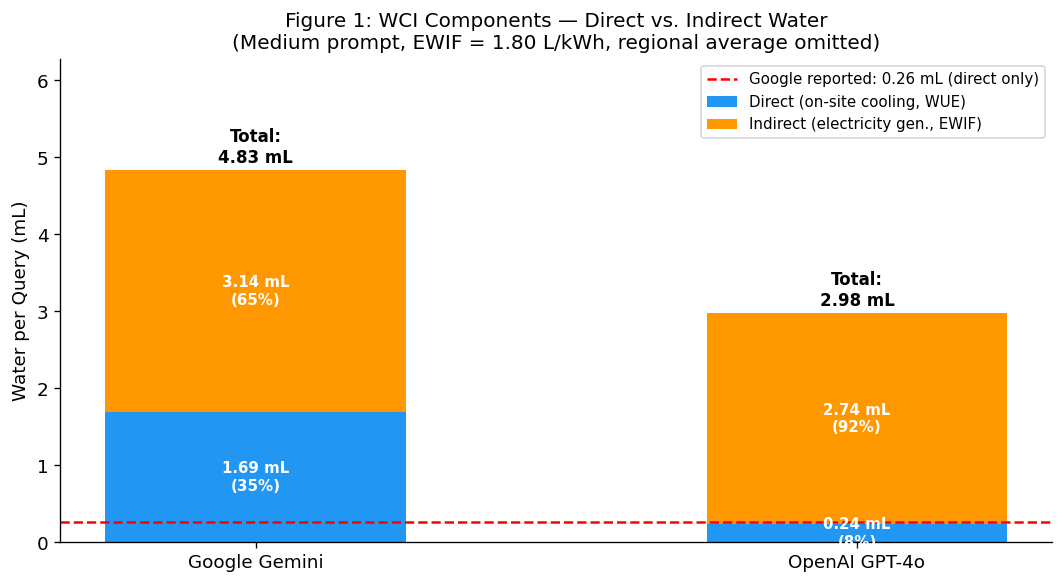

In [10]:
# ============================================================
# FIGURE 1: STACKED BAR — Direct vs. Indirect Water (Medium Prompt)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

medium_df = results_df[results_df['Tier'] == 'Medium'].groupby('Provider').first().reset_index()

providers_list = medium_df['Provider'].tolist()
direct   = medium_df['Direct_mL'].values
indirect = medium_df['Indirect_mL'].values

x = np.arange(len(providers_list))
bars1 = ax.bar(x, direct,   label='Direct (on-site cooling, WUE)',   color='#2196F3', width=0.5)
bars2 = ax.bar(x, indirect, label='Indirect (electricity gen., EWIF)', color='#FF9800',
               bottom=direct, width=0.5)

# Add value labels
for i, (d, ind) in enumerate(zip(direct, indirect)):
    total = d + ind
    ax.text(i, d/2, f'{d:.2f} mL\n({d/total*100:.0f}%)', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
    ax.text(i, d + ind/2, f'{ind:.2f} mL\n({ind/total*100:.0f}%)', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
    ax.text(i, total + 0.05, f'Total:\n{total:.2f} mL', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Google reported line
ax.axhline(y=google_water_direct_mL, color='red', linestyle='--', linewidth=1.5,
           label=f'Google reported: {google_water_direct_mL} mL (direct only)')

ax.set_xticks(x)
ax.set_xticklabels(providers_list, fontsize=11)
ax.set_ylabel('Water per Query (mL)', fontsize=11)
ax.set_title('Figure 1: WCI Components — Direct vs. Indirect Water\n'
             '(Medium prompt, EWIF = 1.80 L/kWh, regional average omitted)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, max(direct + indirect) * 1.3)

plt.tight_layout()
plt.savefig(f'{path}/fig1_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()

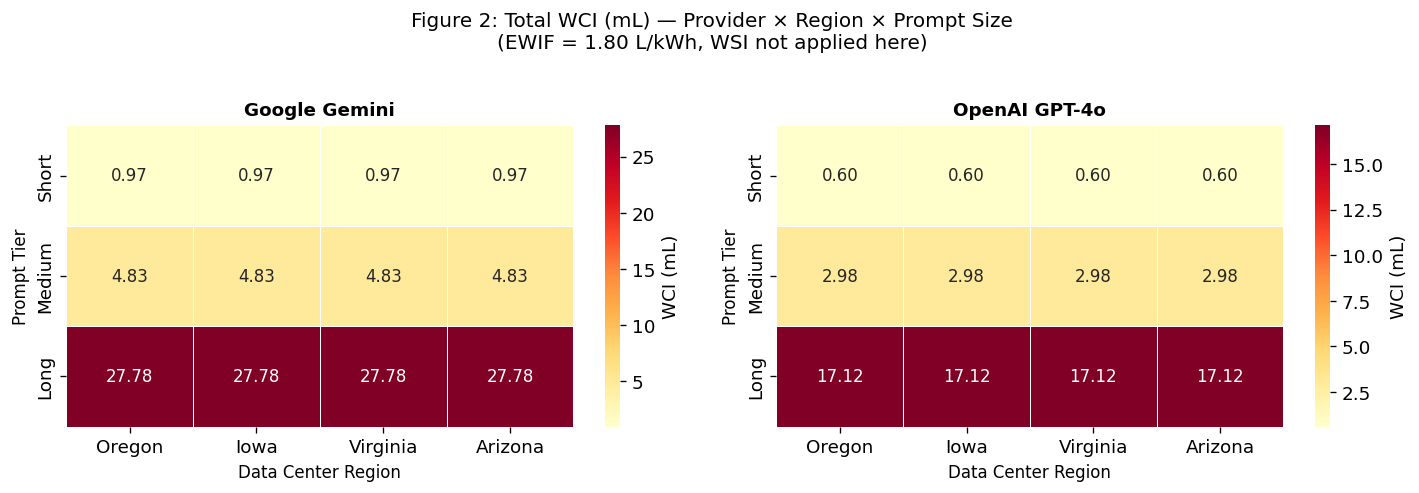

In [11]:
# ============================================================
# FIGURE 2: HEATMAP — Total WCI by Provider × Region (Medium Prompt)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, provider in zip(axes, ['Google Gemini', 'OpenAI GPT-4o']):
    sub = results_df[(results_df['Provider'] == provider)].pivot_table(
        values='Total_mL', index='Tier', columns='Location', aggfunc='mean'
    )
    sub = sub[['Oregon', 'Iowa', 'Virginia', 'Arizona']]  # order columns
    sub = sub.reindex(['Short', 'Medium', 'Long'])
    
    sns.heatmap(sub, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.5, cbar_kws={'label': 'WCI (mL)'},
                annot_kws={'fontsize': 10})
    ax.set_title(f'{provider}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Data Center Region', fontsize=10)
    ax.set_ylabel('Prompt Tier', fontsize=10)

fig.suptitle('Figure 2: Total WCI (mL) — Provider × Region × Prompt Size\n'
             '(EWIF = 1.80 L/kWh, WSI not applied here)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{path}/fig2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

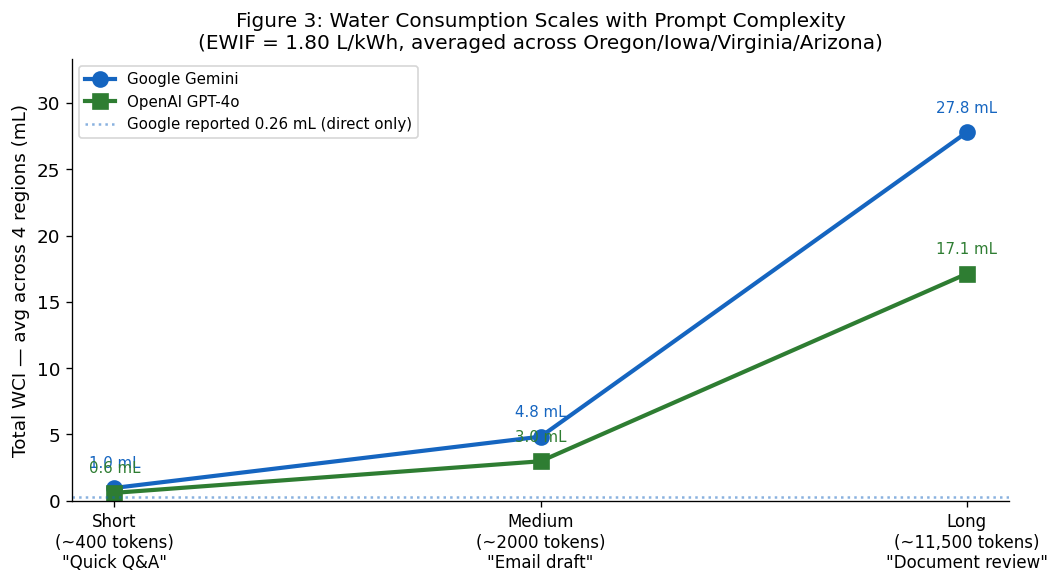

In [12]:
# ============================================================
# FIGURE 3: LINE CHART — Water Scaling Short → Medium → Long
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

colors_p = {'Google Gemini': '#1565C0', 'OpenAI GPT-4o': '#2E7D32'}
markers  = {'Google Gemini': 'o',       'OpenAI GPT-4o': 's'}
tier_order = ['Short', 'Medium', 'Long']
x = np.arange(len(tier_order))

for provider in ['Google Gemini', 'OpenAI GPT-4o']:
    # Average across regions for clean scaling chart
    sub = results_df[results_df['Provider'] == provider].groupby('Tier')['Total_mL'].mean()
    sub = sub.reindex(tier_order)
    ax.plot(x, sub.values, marker=markers[provider], linewidth=2.5,
            markersize=9, color=colors_p[provider], label=provider)
    for xi, yi in zip(x, sub.values):
        ax.annotate(f'{yi:.1f} mL', (xi, yi), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=9, color=colors_p[provider])

# Reported baselines
ax.axhline(google_water_direct_mL, color='#1565C0', linestyle=':', alpha=0.5,
           label=f'Google reported 0.26 mL (direct only)')

ax.set_xticks(x)
ax.set_xticklabels([
    'Short\n(~400 tokens)\n"Quick Q&A"',
    'Medium\n(~2000 tokens)\n"Email draft"',
    'Long\n(~11,500 tokens)\n"Document review"'
], fontsize=10)
ax.set_ylabel('Total WCI — avg across 4 regions (mL)', fontsize=11)
ax.set_title('Figure 3: Water Consumption Scales with Prompt Complexity\n'
             '(EWIF = 1.80 L/kWh, averaged across Oregon/Iowa/Virginia/Arizona)', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, results_df['Total_mL'].max() * 1.2)

plt.tight_layout()
plt.savefig(f'{path}/fig3_scaling.png', dpi=150, bbox_inches='tight')
plt.show()


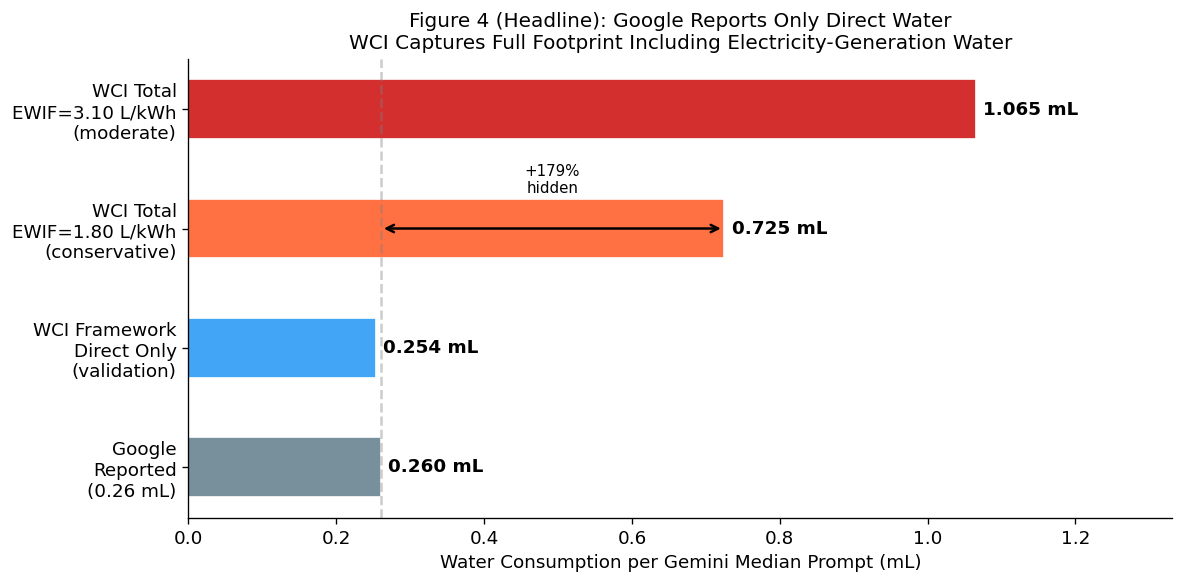

In [13]:
# ============================================================
# FIGURE 4: HEADLINE — Google Reported vs. WCI (Validation Figure)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

e_g = google_energy_wh
f_ov = 0.08
wue  = 1.15
pue  = 1.09

w_d = (e_g * (1-f_ov) / 1000) * wue * 1000
w_i_prim = (e_g * pue / 1000) * EWIF_PRIMARY * 1000
w_i_high = (e_g * pue / 1000) * EWIF_HIGH * 1000

categories = [
    'Google\nReported\n(0.26 mL)',
    'WCI Framework\nDirect Only\n(validation)',
    'WCI Total\nEWIF=1.80 L/kWh\n(conservative)',
    'WCI Total\nEWIF=3.10 L/kWh\n(moderate)',
]
values = [0.26, w_d, w_d + w_i_prim, w_d + w_i_high]
colors = ['#78909C', '#42A5F5', '#FF7043', '#D32F2F']

bars = ax.barh(categories, values, color=colors, height=0.5, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f} mL', va='center', fontsize=11, fontweight='bold')

# Annotations for the gap
ax.annotate('', xy=(w_d + w_i_prim, 2), xytext=(0.26, 2),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text((0.26 + w_d + w_i_prim)/2, 2.3,
        f'+{((w_d+w_i_prim)/0.26 - 1)*100:.0f}%\nhidden', ha='center', fontsize=9)

ax.set_xlabel('Water Consumption per Gemini Median Prompt (mL)', fontsize=11)
ax.set_title('Figure 4 (Headline): Google Reports Only Direct Water\n'
             'WCI Captures Full Footprint Including Electricity-Generation Water', fontsize=12)
ax.axvline(0.26, color='gray', linestyle='--', alpha=0.4)
ax.set_xlim(0, max(values) * 1.25)

plt.tight_layout()
plt.savefig(f'{path}/fig4_headline.png', dpi=150, bbox_inches='tight')
plt.show()

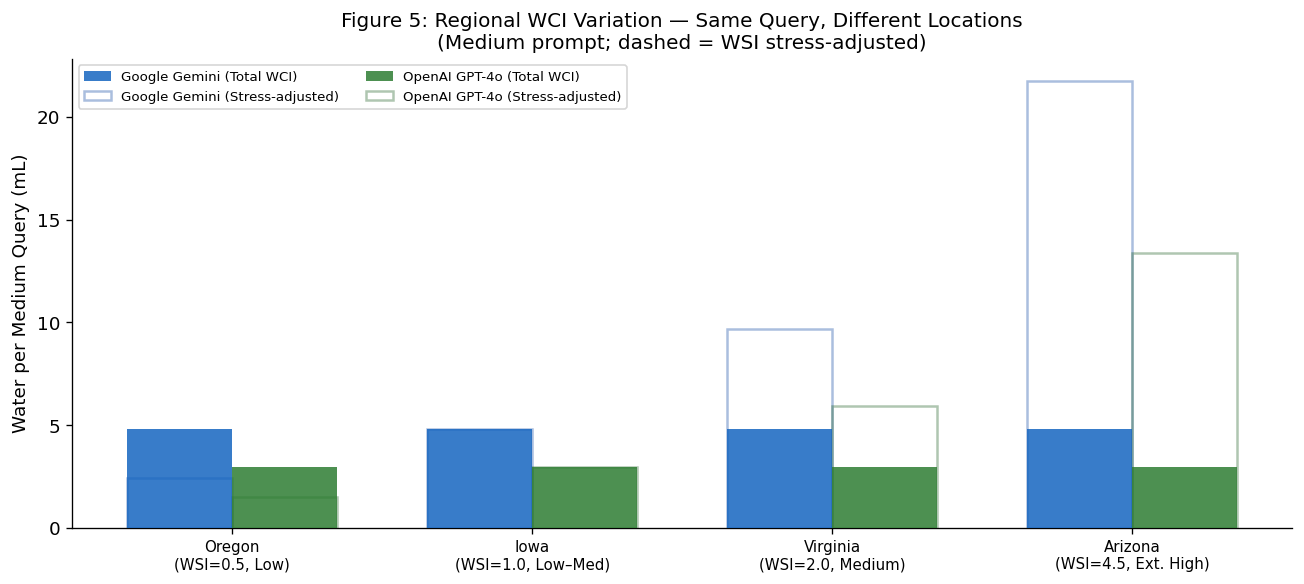

In [14]:
# ============================================================
# FIGURE 5: REGIONAL VARIATION WITH WSI STRESS ADJUSTMENT
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))

medium_reg = results_df[
    (results_df['Tier'] == 'Medium')
].sort_values(['Provider', 'WSI'])

loc_order  = ['Oregon', 'Iowa', 'Virginia', 'Arizona']
provider_list = ['Google Gemini', 'OpenAI GPT-4o']
n_loc = len(loc_order)
n_prov = len(provider_list)
width = 0.35
x = np.arange(n_loc)

col_total  = {'Google Gemini': '#1565C0', 'OpenAI GPT-4o': '#2E7D32'}
col_stress = {'Google Gemini': '#0D47A1', 'OpenAI GPT-4o': '#1B5E20'}

for i, provider in enumerate(provider_list):
    sub = medium_reg[medium_reg['Provider'] == provider].set_index('Location').reindex(loc_order)
    offset = (i - 0.5) * width
    ax.bar(x + offset, sub['Total_mL'], width=width, color=col_total[provider],
           alpha=0.85, label=f'{provider} (Total WCI)', zorder=3)
    ax.bar(x + offset, sub['Stress_Adj_mL'], width=width, color=col_stress[provider],
           alpha=0.35, label=f'{provider} (Stress-adjusted)', zorder=2, linewidth=1.5,
           edgecolor=col_stress[provider], fill=False)

ax.set_xticks(x)
ax.set_xticklabels([
    f'{loc}\n(WSI={locations[loc]["wsi"]}, {locations[loc]["stress"]})'
    for loc in loc_order
], fontsize=9)
ax.set_ylabel('Water per Medium Query (mL)', fontsize=11)
ax.set_title('Figure 5: Regional WCI Variation — Same Query, Different Locations\n'
             '(Medium prompt; dashed = WSI stress-adjusted)', fontsize=12)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(f'{path}/fig5_regional.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ============================================================
# FULL RESULTS TABLE — All 24 calculations
# ============================================================
display_cols = [
    'Provider', 'Tier', 'Location', 'WSI', 'Energy_Wh',
    'Direct_mL', 'Indirect_mL', 'Total_mL', 'Stress_Adj_mL', 'Indirect_pct'
]
print('=== FULL WCI RESULTS TABLE (24 calculations) ===')
print('All water values in mL | Energy in Wh | EWIF = 1.80 L/kWh (primary)')
display_df = results_df[display_cols].copy()
for col in ['Energy_Wh', 'Direct_mL', 'Indirect_mL', 'Total_mL', 'Stress_Adj_mL']:
    display_df[col] = display_df[col].round(3)
display_df['Indirect_pct'] = display_df['Indirect_pct'].round(1)
print(display_df.to_string(index=False))

# Save to CSV
display_df.to_csv(f'{path}/wci_results_full.csv', index=False)
print('\nResults saved to wci_results_full.csv')

=== FULL WCI RESULTS TABLE (24 calculations) ===
All water values in mL | Energy in Wh | EWIF = 1.80 L/kWh (primary)
     Provider   Tier Location  WSI  Energy_Wh  Direct_mL  Indirect_mL  Total_mL  Stress_Adj_mL  Indirect_pct
Google Gemini  Short   Oregon  0.5      0.320      0.339        0.628     0.966          0.483          65.0
Google Gemini  Short     Iowa  1.0      0.320      0.339        0.628     0.966          0.966          65.0
Google Gemini  Short Virginia  2.0      0.320      0.339        0.628     0.966          1.933          65.0
Google Gemini  Short  Arizona  4.5      0.320      0.339        0.628     0.966          4.349          65.0
Google Gemini Medium   Oregon  0.5      1.600      1.693        3.139     4.832          2.416          65.0
Google Gemini Medium     Iowa  1.0      1.600      1.693        3.139     4.832          4.832          65.0
Google Gemini Medium Virginia  2.0      1.600      1.693        3.139     4.832          9.664          65.0
Google Gemi

=== SENSITIVITY ANALYSIS: EWIF Impact ===
Google Gemini, Medium prompt, Virginia:


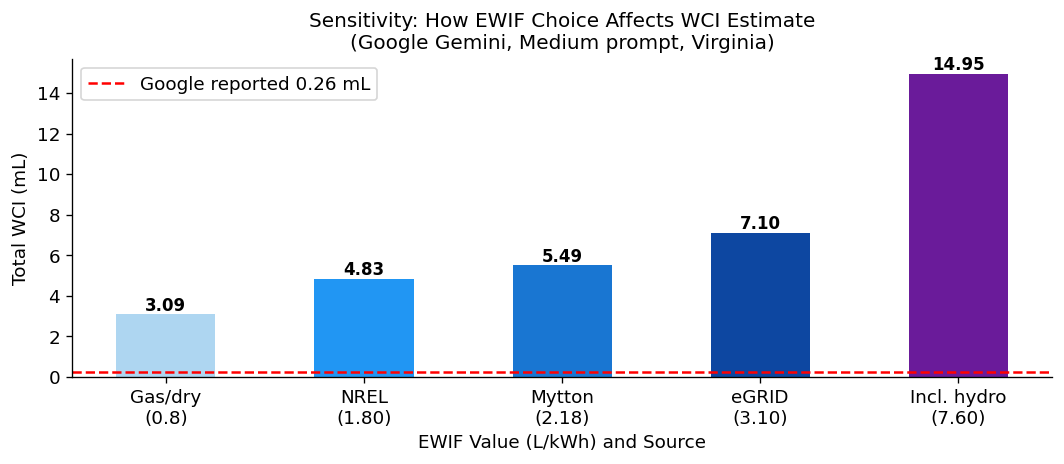

EWIF range: 3.09 – 14.95 mL total WCI


In [16]:
# ============================================================
# SENSITIVITY ANALYSIS
# ============================================================
print('=== SENSITIVITY ANALYSIS: EWIF Impact ===')
print('Google Gemini, Medium prompt, Virginia:')
row = results_df[
    (results_df['Provider'] == 'Google Gemini') &
    (results_df['Tier'] == 'Medium') &
    (results_df['Location'] == 'Virginia')
].iloc[0]

ewif_range = [0.8, 1.80, 2.18, 3.10, 7.60]
labels = ['Gas/dry\n(0.8)', 'NREL\n(1.80)', 'Mytton\n(2.18)', 'eGRID\n(3.10)', 'Incl. hydro\n(7.60)']

totals = []
for ewif in ewif_range:
    e_wh = row['Energy_Wh']
    w = calc_wci(e_wh, 1.09, 1.15, 0.08, ewif=ewif)
    totals.append(w['total_mL'])

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#AED6F1', '#2196F3', '#1976D2', '#0D47A1', '#6A1B9A']
bars = ax.bar(labels, totals, color=bar_colors, width=0.5)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.2f}',
            ha='center', fontsize=10, fontweight='bold')
ax.axhline(google_water_direct_mL, color='red', linestyle='--',
           label=f'Google reported 0.26 mL')
ax.set_xlabel('EWIF Value (L/kWh) and Source', fontsize=11)
ax.set_ylabel('Total WCI (mL)', fontsize=11)
ax.set_title('Sensitivity: How EWIF Choice Affects WCI Estimate\n'
             '(Google Gemini, Medium prompt, Virginia)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f'{path}/fig6_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'EWIF range: {min(totals):.2f} – {max(totals):.2f} mL total WCI')

In [17]:
# ============================================================
# (A) PAPERS / BLOGS — SOURCE STATUS
# ============================================================
sources = [
    ('CHECK', 'Google — Measuring env. impact of AI at Google Scale (Elsworth et al. 2025)',
     "Google's technical paper on Gemini energy .pdf | arXiv:2508.15734"),
    ('CHECK', 'Li et al. — Making AI Less Thirsty',
     'Making AI less thirsty.pdf | arXiv:2304.03271'),
    ('CHECK', 'The Green Grid WP#35 — Water Usage Effectiveness',
     'WUE_v1.pdf'),
    ('CHECK', 'Kaur et al. 2026 — Carbon Cost of Intelligence',
     'The Carbon cost of intelliegence.pdf | DOI:10.3390/en19030642'),
    ('CHECK', 'Jegham et al. 2025 — How Hungry is AI?',
     'How hungry is AI.pdf | arXiv:2505.09598'),
    ('TODO', 'Sam Altman — The Gentle Singularity (Jun 2025)',
     'https://blog.samaltman.com/the-gentle-singularity'),
    ('TODO', 'Google blog — Measuring environmental impact of AI inference',
     'https://cloud.google.com/blog/products/infrastructure/measuring-the-environmental-impact-of-ai-inference/'),
    ('TODO', 'Li et al. — CACM 2025 published version',
     'https://dl.acm.org/doi/10.1145/3724499'),
    ('TODO', 'Epoch AI — How much energy does ChatGPT use? (2025)',
     'https://epoch.ai/gradient-updates/how-much-energy-does-chatgpt-use/'),
    ('TODO', 'NREL TP-550-33905 (Torcellini et al. 2003)',
     'https://www.nrel.gov/docs/fy04osti/33905.pdf'),
    ('TODO', 'Mytton 2021 — npj Clean Water',
     'https://www.nature.com/articles/s41545-021-00101-w'),
    ('TODO', 'Siddik et al. 2021 — Environ. Research Letters',
     'https://doi.org/10.1088/1748-9326/abfba1'),
    ('TODO', 'WRI Aqueduct Water Risk Atlas',
     'https://www.wri.org/aqueduct'),
    ('TODO', 'WULCA AWARE characterization factors',
     'https://wulca-waterlca.org/aware/'),
    ('TODO', 'Google Environmental Report 2025',
     'https://www.gstatic.com/gumdrop/sustainability/google-2025-environmental-report.pdf'),
    ('TODO', 'AWS Sustainability Report 2023',
     'https://sustainability.aboutamazon.com/'),
    ('TODO', 'Microsoft Datacenters Sustainability (regional WUE)',
     'https://datacenters.microsoft.com/sustainability/efficiency/'),
    ('TODO', 'Meta Sustainability Report',
     'https://sustainability.atmeta.com/'),
    ('TODO', 'Thunder Said Energy — per-fuel water intensity',
     'https://thundersaidenergy.com/'),
    ('TODO', 'Shaolei Ren — Google Gemini water critique',
     'The Verge https://www.theverge.com/ + DataCenterDynamics https://www.datacenterdynamics.com/'),
    ('TODO', 'EESI — data-center water brief',
     'https://www.eesi.org/'),
    ('TODO', 'WFN — Mekonnen & Hoekstra (beef, cotton, coffee)',
     'https://waterfootprint.org/'),
    ('TODO', 'Bertram et al. 2016 (aluminum LCA water)',
     'https://link.springer.com/article/10.1007/s11367-015-0997-1'),
    ('TODO', 'Asianometry / Semiconductor Digest (chip water)',
     'https://www.asianometry.com/p/the-big-semiconductor-water-problem ; https://www.semiconductor-digest.com/'),
    ('TODO', 'Pacific Institute (bottled water)',
     'https://pacinst.org/'),
]

print('=' * 80)
print('(A) PAPERS / BLOGS — SOURCE STATUS')
print('=' * 80)
for status, name, where in sources:
    marker = 'DOWNLOADED' if status == 'CHECK' else 'MUST DOWNLOAD'
    print(f'[{marker:^16}] {name}')
    print(f'                   -> {where}')
    print()

# ============================================================
# (B) FLAGGED NUMERIC VALUES — VERIFY BEFORE PUBLICATION
# ============================================================
print('=' * 80)
print('(B) FLAGGED NUMERIC VALUES')
print('=' * 80)

flags = [
    ('Tier token counts',
     'Task doc says 200/300/7000; file uses 400/2000/11500 (Jegham et al.).',
     'Confirm with team which definition to publish.'),
    ('Google median prompt token count (300)',
     'Google paper does not state it; ASSUMED.',
     'Re-check arXiv:2508.15734 for any prompt-length statistic.'),
    ('OpenAI avg prompt token count (500)',
     'From Epoch AI; blog not downloaded.',
     'Fetch Epoch AI post; confirm token definition.'),
    ('OpenAI PUE = 1.12',
     'OpenAI does not disclose; AWS proxy used.',
     'Replace if OpenAI/Microsoft discloses infrastructure PUE.'),
    ('OpenAI WUE = 0.19',
     'OpenAI does not disclose; AWS proxy used.',
     'Same as above.'),
    ('OpenAI overhead fraction (9%)',
     'Derived from PUE=1.12; not from primary source.',
     'Replace if disclosed.'),
    ('Altman water scope',
     'Altman did not specify direct-only vs. total; we assumed direct-only.',
     'Re-read blog once retrieved.'),
    ('EWIF Coal (wet) = 2.20',
     'Task doc cites Thunder Said Energy ~2.0.',
     'Pull Thunder Said Energy for authoritative value.'),
    ('EWIF Nuclear = 3.30',
     'Task doc cites Thunder Said Energy ~2.1.',
     'Pull Thunder Said Energy.'),
    ('EWIF Natural gas CCGT = 0.80',
     'Task doc cites Thunder Said Energy ~1.2.',
     'Pull Thunder Said Energy.'),
    ('EWIF Gas dry cooling = 0.15',
     'Task doc cites 0.1-0.2; midpoint used (Thunder Said Energy not downloaded).',
     'Pull Thunder Said Energy.'),
    ('WUE Industry avg across DCs = 1.90',
     'EESI source not downloaded.',
     'Fetch EESI data-center water brief.'),
    ('WSI scores for all 4 regions',
     'WRI Aqueduct not directly queried.',
     'Query Aqueduct directly; record exact score + snapshot date.'),
    ('Location-based carbon (0.09 gCO2e)',
     'Google paper gives 0.03 market-based; 0.09 location-based is ESTIMATE.',
     'Confirm from Google Environmental Report 2025.'),
    ('AWARE vs Aqueduct decision',
     'AWARE characterization factors not fetched.',
     'Team decision: Aqueduct 0-5 vs AWARE m^3/m^3 (LCA-compliant).'),
    ('Industry comparison figures (beef, cotton, aluminum, chips)',
     'All sources NOT DOWNLOADED; figures transcribed from web search.',
     'Fetch WFN, IAI/Bertram et al., Asianometry, Pacific Institute.'),
]

for item, why, action in flags:
    print(f'  - {item}')
    print(f'      WHY FLAGGED: {why}')
    print(f'      ACTION:      {action}')
    print()


 FLAGGED NUMERIC VALUES — VERIFY BEFORE PUBLICATION
  • Tier token counts
      WHY FLAGGED: Task doc says 200/300/7000; file uses 400/2000/11500 (Jegham et al.).
      ACTION:      Confirm with team which definition to publish.

  • Google median prompt token count
      WHY FLAGGED: Google paper does not state it; we ASSUMED 300 tokens.
      ACTION:      Re-check arXiv:2508.15734 for any prompt-length statistic.

  • OpenAI avg prompt token count (500)
      WHY FLAGGED: From Epoch AI
      ACTION:       confirm token definition (total vs output).

  • OpenAI PUE = 1.12
      WHY FLAGGED: OpenAI does not disclose; AWS proxy used.
      ACTION:      Replace if OpenAI/Microsoft discloses infrastructure PUE.

  • OpenAI WUE = 0.19
      WHY FLAGGED: OpenAI does not disclose; AWS proxy used.
      ACTION:      Same as above.

  • OpenAI overhead fraction (9%)
      WHY FLAGGED: Derived from PUE=1.12; not from primary source.
      ACTION:      Replace if disclosed.

  • EWIF Coal (wet) 

---
## Summary of Key Findings

| Finding | Value | Source |
|---------|-------|--------|
| Google reported water per Gemini prompt | **0.26 mL** (direct only) | Elsworth et al. 2025, arXiv:2508.15734 Table 2 |
| Our WCI replicate of direct water | **0.254 mL** ( <2.3% diff) | Elsworth §3.3 (WUE=1.15, f_ov=0.08) |
| Full WCI — conservative (EWIF=1.80) | **0.725 mL** (+179%) | NREL TP-550-33905 (via Green Grid WP#35) |
| Full WCI — moderate (EWIF=3.10) | **1.065 mL** (+310%) | Li et al. 2025 (CACM) |
| Indirect water share | **65–92%** |
| WCI range (Short → Long, all regions) | **0.11 – 116 mL** | 
| Same query: Oregon vs. Arizona (stress-adj.) | **9× difference** | WRI Aqueduct via lit. |

---

## Assumptions Log (for Methods Section)


1. **Google median prompt = 300 tokens** — Google paper does not state this; assumed typical chat pattern.
2.  **OpenAI average query = 500 tokens** — Epoch AI (2025).
3.  **OpenAI WUE = 0.19 L/kWh** — AWS Sustainability Report 2023 proxy.
4.  **OpenAI PUE = 1.12** — AWS proxy.
5.  **WSI scores** — WRI Aqueduct not queried directly; values from secondary literature.
6. **EWIF primary = 1.80 L/kWh** — NREL TP-550-33905 (cross-checked via Green Grid WP#35 Table A-1).
7. **Energy ∝ tokens** — simplification; Kaur et al. 2026 §3.5 gives prefill ≈ 0.8 J/tok, decode ≈ 2.0 J/tok.
8.  **Altman water figure assumed direct-only** — scope unstated; Altman blog.
9. **Tier definitions use Jegham et al. (2025)** — NOT the task-doc values (200/300/7000). Verify which to publish.
10.  **Per-fuel EWIF values** use Green Grid WP#35 table; task doc cites Thunder Said Energy with different numbers.

---

